### 서울시 행정동별 요양시설 유효공급 격차 ③ 공급 정리와 품질 가중

E2SFCA의 공급은 정원에 품질 가중치를 곱한 '유효 공급'으로 둔다.

$$S_j = \text{정원}_j \times q_j$$

$q_j$는 임의로 정하지 않고 데이터로 정한다. 이용자가 평가등급이 낮은 시설을 피한다면 등급이 낮을수록 가동률이 낮아야 하므로, 등급별 가동률의 비를 '정원 1석이 실제로 수요를 흡수하는 정도'로 해석해 가중치로 쓴다. 서울은 가동률이 전반적으로 높아 등급 간 차이가 눌려 있고 등급별 시설 수도 적으므로, 추정은 전국 입소시설 자료로 하고 서울에서 방향이 같은지 확인한다.

### 1. 분석 기준

- 평가 자료: 국민건강보험공단 장기요양기관 평가 결과(포털 게시본 2026-06-25). 입소시설은 3년 주기로 평가하며, 기준 시점(2024-07)에 유효한 등급은 **2021년 정기평가**(평가일 2021-04~2022-11, 코로나19로 2022년까지 연장)다. 같은 파일의 2025년 정기평가는 기준 시점 이후 자료이므로 미평가 시설 처리의 민감도에만 쓴다.
- 결합 키: 평가 자료의 `장기요양기관기호`(예: `1-11560-00018`)에서 `-`를 지우면 시설 파일의 11자리 `장기요양기관코드`와 같다.
- 가동률: 시설 파일(2024-07-16)의 `현원 ÷ 정원`, 입소시설 A01~A05
- q 방식(설정 `Q_METHOD`)
  - `occupancy`(기본): $q_g = \text{가동률}_g / \text{가동률}_A$. 가동률은 등급 안 시설의 현원 합 ÷ 정원 합이며, 시설 단위 층화 부트스트랩으로 신뢰구간을 구한다.
  - `regression`(보강): 분수 로짓 $\text{logit}\,E[\text{가동률}] = \text{등급} + \log(\text{정원}) + \text{공동생활가정} + \text{시도}$로 등급 효과를 추정하고, 모든 시설의 등급을 g로 바꿔 예측한 평균 가동률의 비를 q로 쓴다.
  - `binary`: A·B등급 1, 나머지 0.5 / `none`: 모두 1
- 미평가 시설(설정 `UNRATED_Q`): `seoul_mean`(기본, 서울 평가 시설의 정원가중 평균 q) / `separate`(미평가를 별도 범주로 두고 가동률로 q 추정) / `rating2025`(2025년 정기평가 등급이 있으면 그 등급의 q, 없으면 서울 평균)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
import requests
from IPython.display import display, Markdown

import config as C

pd.set_option("display.max_rows", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

plt.rcParams["font.family"] = ["AppleGothic", "Arial Unicode MS", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

GRADES = ["A", "B", "C", "D", "E"]
rng = np.random.default_rng(20240716)

### 2. 평가 자료와 시설 파일 결합

In [2]:
if not C.EVAL_FILE.exists():
    r = requests.get(C.EVAL_URL, timeout=120)
    r.raise_for_status()
    C.EVAL_FILE.write_bytes(r.content)

evaluation = pd.read_csv(C.EVAL_FILE, encoding="cp949", dtype=str)
evaluation["장기요양기관코드"] = evaluation["장기요양기관기호"].str.replace("-", "", regex=False)
evaluation = evaluation.loc[evaluation["급여종류"].str.match(r"^0[123]\.")]  # 입소시설 세 규모
assert evaluation["장기요양기관코드"].str.len().eq(11).all()

rating = (
    evaluation.loc[evaluation["평가구분"].eq(C.EVAL_CYCLE), ["장기요양기관코드", "평가등급", "평가일자"]]
)
assert rating["장기요양기관코드"].is_unique
rating_2025 = (
    evaluation.loc[evaluation["평가구분"].eq("2025년 정기평가"), ["장기요양기관코드", "평가등급"]]
    .rename(columns={"평가등급": "평가등급_2025"})
)
assert rating_2025["장기요양기관코드"].is_unique

general = pd.read_excel(C.FACILITY_FILE, sheet_name="일반현황", dtype={"장기요양기관코드": str})
capacity = pd.read_excel(C.FACILITY_FILE, sheet_name="입소인원", dtype={"장기요양기관코드": str})
region = general["시도 시군구 법정동명"].str.extract(r"^(\S+)\s+(\S+)")
region_fallback = general["기관별 상세주소"].str.extract(r"^(\S+)\s+(\S+)")
general["시도"] = region[0].fillna(region_fallback[0])
general["지정일자"] = pd.to_datetime(general["지정일자"])

facility = (
    capacity.loc[capacity["기관유형코드"].isin(C.RESIDENTIAL_CODES)]
    .groupby("장기요양기관코드", as_index=False)
    .agg(기관유형코드=("기관유형코드", "+".join), 정원=("정원", "sum"), 현원=("현원", "sum"))
    .merge(general[["장기요양기관코드", "장기요양기관이름", "시도", "지정일자"]], on="장기요양기관코드", validate="one_to_one")
    .merge(rating, on="장기요양기관코드", how="left", validate="one_to_one")
    .merge(rating_2025, on="장기요양기관코드", how="left", validate="one_to_one")
)
facility = facility.loc[facility["정원"] > 0].reset_index(drop=True)
facility["등급"] = facility["평가등급"].fillna("미평가")
facility["공동생활가정"] = facility["기관유형코드"].str.contains("A04").astype(int)
facility["가동률"] = facility["현원"] / facility["정원"]
facility["서울"] = facility["시도"].eq("서울특별시")

join_table = facility.groupby("서울").agg(
    시설수=("장기요양기관코드", "size"),
    평가결합=("평가등급", lambda s: s.notna().sum()),
    정원=("정원", "sum"),
    평가결합_정원=("정원", lambda s: s[facility.loc[s.index, "평가등급"].notna()].sum()),
).rename(index={True: "서울", False: "서울 외"})
join_table.loc["전국"] = join_table.sum()
join_table["결합률(시설)"] = join_table["평가결합"] / join_table["시설수"]
join_table["결합률(정원)"] = join_table["평가결합_정원"] / join_table["정원"]
display(join_table.style.format({
    "시설수": "{:,.0f}", "평가결합": "{:,.0f}", "정원": "{:,.0f}", "평가결합_정원": "{:,.0f}",
    "결합률(시설)": "{:.1%}", "결합률(정원)": "{:.1%}",
}))

unrated = facility.loc[facility["평가등급"].isna()]
rated = facility.loc[facility["평가등급"].notna()]
display(Markdown(
    f"- 2021년 평가 결합 시설의 지정일자는 모두 {rated['지정일자'].max():%Y-%m-%d} 이전이다.\n"
    f"- 미평가 시설 {len(unrated):,}곳 중 {(unrated['지정일자'] >= '2020-01-01').mean():.1%}가 2020년 이후 지정 시설이다. "
    f"2020년 이전 지정인데 미평가인 시설은 {(unrated['지정일자'] < '2020-01-01').sum()}곳이다.\n"
    f"- 미평가 시설 중 2025년 정기평가 등급이 있는 시설: {unrated['평가등급_2025'].notna().sum():,}곳"
))
assert rated["지정일자"].max() < pd.Timestamp("2020-01-01")

,시설수,평가결합,정원,평가결합_정원,결합률(시설),결합률(정원)
서울,,,,,,
서울 외,"5,779","3,529","230,055","144,817",61.1%,62.9%
서울,484,347,"16,055","12,453",71.7%,77.6%
전국,"6,263","3,876","246,110","157,270",61.9%,63.9%


- 2021년 평가 결합 시설의 지정일자는 모두 2019-12-31 이전이다.
- 미평가 시설 2,387곳 중 96.1%가 2020년 이후 지정 시설이다. 2020년 이전 지정인데 미평가인 시설은 94곳이다.
- 미평가 시설 중 2025년 정기평가 등급이 있는 시설: 1,811곳

### 3. 등급별 가동률

가동률이 100%를 넘는 시설(정원 변경 시점 차이 등)은 1로 자른다. 등급별 가동률은 등급 안 시설의 현원 합 ÷ 정원 합(정원 가중)이다. 부트스트랩은 등급 안에서 시설을 복원추출해 등급별 가동률과 A등급 대비 비를 다시 계산한다.

In [3]:
facility["가동률_절단"] = facility["가동률"].clip(upper=1)
facility["현원_절단"] = facility["가동률_절단"] * facility["정원"]
over = (facility["가동률"] > 1).sum()


def pooled_occupancy(df):
    g = df.groupby("등급")[["현원_절단", "정원"]].sum()
    return g["현원_절단"] / g["정원"]


def bootstrap(df, n):
    groups = {g: d[["현원_절단", "정원"]].to_numpy() for g, d in df.groupby("등급")}
    rows = []
    for _ in range(n):
        occ = {}
        for g, arr in groups.items():
            s = arr[rng.integers(0, len(arr), len(arr))]
            occ[g] = s[:, 0].sum() / s[:, 1].sum()
        rows.append(occ)
    return pd.DataFrame(rows)


order = GRADES + ["미평가"]
occ_nat = pooled_occupancy(facility).reindex(order)
occ_seoul = pooled_occupancy(facility.loc[facility["서울"]]).reindex(order)
boot = bootstrap(facility, C.N_BOOTSTRAP)[order]
boot_q = boot.div(boot["A"], axis=0)

occupancy_table = pd.DataFrame({
    "시설수(전국)": facility.groupby("등급").size().reindex(order),
    "정원(전국)": facility.groupby("등급")["정원"].sum().reindex(order),
    "가동률(전국)": occ_nat,
    "가동률 95% CI": [f"{boot[g].quantile(0.025):.1%} ~ {boot[g].quantile(0.975):.1%}" for g in order],
    "q = 가동률÷가동률A": occ_nat / occ_nat["A"],
    "q 95% CI": [f"{boot_q[g].quantile(0.025):.3f} ~ {boot_q[g].quantile(0.975):.3f}" for g in order],
    "만실 비율(전국)": facility.assign(만실=facility["정원"] - facility["현원"] <= 1).groupby("등급")["만실"].mean().reindex(order),
    "시설수(서울)": facility.loc[facility["서울"]].groupby("등급").size().reindex(order),
    "가동률(서울)": occ_seoul,
})
print(f"가동률이 100%를 넘어 1로 자른 시설: {over}곳")
display(occupancy_table.style.format({
    "시설수(전국)": "{:,.0f}", "정원(전국)": "{:,.0f}", "가동률(전국)": "{:.1%}", "q = 가동률÷가동률A": "{:.3f}",
    "만실 비율(전국)": "{:.1%}", "시설수(서울)": "{:,.0f}", "가동률(서울)": "{:.1%}",
}))

가동률이 100%를 넘어 1로 자른 시설: 114곳


,시설수(전국),정원(전국),가동률(전국),가동률 95% CI,q = 가동률÷가동률A,q 95% CI,만실 비율(전국),시설수(서울),가동률(서울)
등급,,,,,,,,,
A,714,"41,897",87.9%,86.4% ~ 89.3%,1.000,1.000 ~ 1.000,44.4%,45,97.2%
B,"1,079","47,533",84.3%,82.8% ~ 85.7%,0.960,0.937 ~ 0.982,44.5%,100,91.9%
C,940,"32,935",80.2%,78.5% ~ 81.8%,0.912,0.889 ~ 0.937,44.8%,103,90.8%
D,520,"14,937",78.7%,76.0% ~ 81.2%,0.896,0.862 ~ 0.929,43.7%,48,90.7%
E,623,"19,968",72.5%,68.9% ~ 75.3%,0.825,0.784 ~ 0.860,36.6%,51,84.3%
미평가,"2,387","88,840",80.3%,79.2% ~ 81.4%,0.914,0.895 ~ 0.934,41.2%,137,85.9%


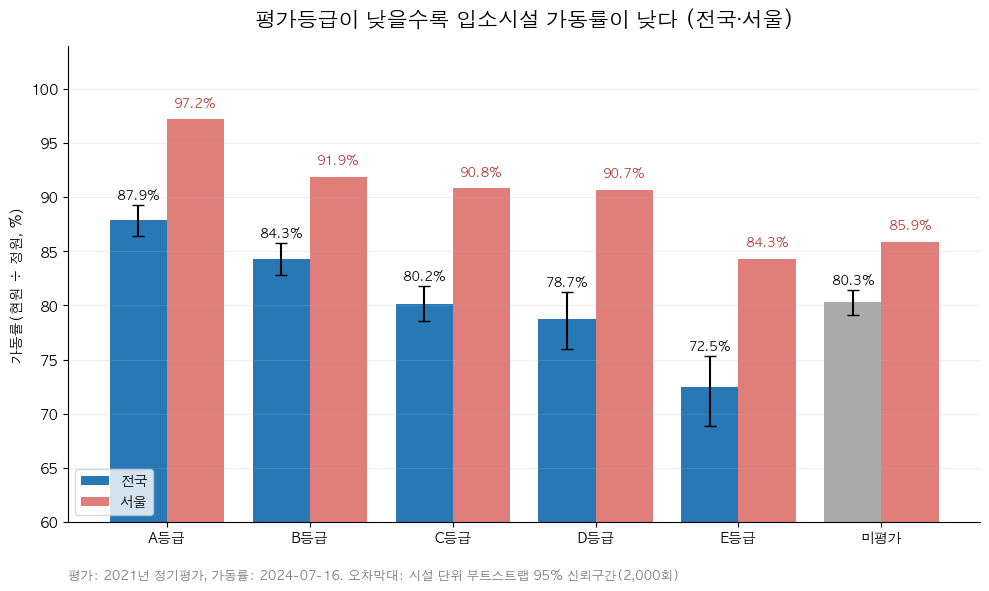

In [4]:
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(order))
lo = boot.quantile(0.025)[order].to_numpy()
hi = boot.quantile(0.975)[order].to_numpy()
ax.bar(x - 0.2, occ_nat * 100, width=0.4, color=["#2878B5"] * 5 + ["#AAAAAA"], label="전국",
       yerr=[(occ_nat - lo) * 100, (hi - occ_nat) * 100], capsize=4)
ax.bar(x + 0.2, occ_seoul * 100, width=0.4, color="#D95F59", alpha=0.8, label="서울")
for xi, v, top in zip(x, occ_nat, hi):
    ax.text(xi - 0.2, top * 100 + 0.6, f"{v:.1%}", ha="center", fontsize=9)
for xi, v in zip(x, occ_seoul):
    ax.text(xi + 0.2, v * 100 + 1.2, f"{v:.1%}", ha="center", fontsize=9, color="#B03A35")
ax.set_xticks(x, [f"{g}등급" if g in GRADES else g for g in order])
ax.set_ylim(60, 104)
ax.set_ylabel("가동률(현원 ÷ 정원, %)")
ax.set_title("평가등급이 낮을수록 입소시설 가동률이 낮다 (전국·서울)", fontsize=15, pad=14)
ax.grid(axis="y", alpha=0.2)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(loc="lower left")
ax.text(0, -0.12, f"평가: {C.EVAL_CYCLE}, 가동률: 2024-07-16. 오차막대: 시설 단위 부트스트랩 95% 신뢰구간({C.N_BOOTSTRAP:,}회)",
        transform=ax.transAxes, fontsize=9, color="#777777")
plt.tight_layout()
fig.savefig(C.OUTPUT_DIR / "등급별_가동률.png", dpi=200, bbox_inches="tight")
plt.show()

### 4. 보강: 규모·유형·지역을 통제한 등급 효과

등급이 낮은 시설이 작거나 수요가 적은 지역에 몰려 있으면 3절의 가동률 차이는 등급이 아니라 규모·지역 차이일 수 있다. 분수 로짓(이항 GLM, 정원 가중, 강건 표준오차)으로 정원 규모(log), 공동생활가정 여부, 시도를 통제한 뒤 등급 효과를 추정한다. 미평가 시설도 별도 범주로 넣는다.

In [5]:
model_df = facility.assign(log정원=np.log(facility["정원"]), 등급=pd.Categorical(facility["등급"], categories=order))
frac_logit = smf.glm(
    "가동률_절단 ~ 등급 + log정원 + 공동생활가정 + 시도",  # 등급은 A가 첫 범주(기준)
    data=model_df, family=sm.families.Binomial(), var_weights=model_df["정원"],
).fit(cov_type="HC0")

coef = frac_logit.params.filter(like="등급")
ci = frac_logit.conf_int().loc[coef.index]
reg_table = pd.DataFrame({
    "계수(logit)": coef, "95% 하한": ci[0], "95% 상한": ci[1], "p": frac_logit.pvalues.loc[coef.index],
})
reg_table.index = [i.split("T.")[-1].rstrip("]") for i in reg_table.index]
assert list(reg_table.index) == order[1:]

# 평균 예측 가동률 비: 모든 시설의 등급을 g로 바꿔 예측한 가동률의 정원가중 평균 ÷ A등급일 때
recycled = {}
for g in order:
    pred = frac_logit.predict(model_df.assign(등급=pd.Categorical([g] * len(model_df), categories=order)))
    recycled[g] = np.average(pred, weights=model_df["정원"])
q_reg = pd.Series(recycled) / recycled["A"]
reg_table["q(회귀)"] = q_reg.reindex(reg_table.index)
display(reg_table.style.format({"계수(logit)": "{:.3f}", "95% 하한": "{:.3f}", "95% 상한": "{:.3f}", "p": "{:.4f}", "q(회귀)": "{:.3f}"}))
print(f"A등급 기준 q(회귀) = 1.000, 관측 시설 {int(frac_logit.nobs):,}곳")

,계수(logit),95% 하한,95% 상한,p,q(회귀)
B,-0.373,-0.532,-0.214,0.0000,0.953
C,-0.730,-0.889,-0.572,0.0000,0.895
D,-0.876,-1.071,-0.682,0.0000,0.867
E,-1.154,-1.357,-0.951,0.0000,0.809
미평가,-0.710,-0.857,-0.562,0.0000,0.899


A등급 기준 q(회귀) = 1.000, 관측 시설 6,263곳


### 5. q 표

In [6]:
q_occ = occ_nat / occ_nat["A"]
q_table = pd.DataFrame({
    "occupancy": q_occ.reindex(order),
    "regression": q_reg.reindex(order),
    "binary": pd.Series({"A": 1, "B": 1, "C": 0.5, "D": 0.5, "E": 0.5}).reindex(order),
    "none": 1.0,
})
q_table.loc["미평가", "binary"] = np.nan  # 미평가 처리는 UNRATED_Q로 정한다

# 등급 순서 점검: 기본 방식에서 등급이 낮을수록 q가 커지지 않는다.
assert (q_table.loc[GRADES, "occupancy"].diff().dropna() <= 0.01).all(), q_table
q_table.to_csv(C.OUTPUT_DIR / "q_표.csv")
display(q_table.style.format("{:.3f}", na_rep="-"))

,occupancy,regression,binary,none
A,1.000,1.000,1.000,1.000
B,0.960,0.953,1.000,1.000
C,0.912,0.895,0.500,1.000
D,0.896,0.867,0.500,1.000
E,0.825,0.809,0.500,1.000
미평가,0.914,0.899,-,1.000


### 6. 분석 범위 시설의 공급 S_j

01 노트북의 분석 범위 시설(서울 + 버퍼)에 q를 붙인다. 모든 q 방식 × 미평가 처리 조합의 `S_j`를 열로 저장해 3단계 민감도 분석에서 설정만 바꿔 쓴다. 서울 평균 q는 서울 평가 시설의 정원가중 평균이다.

In [7]:
study_fac = pd.read_csv(C.OUTPUT_DIR / "입소시설_분석범위.csv", dtype={"장기요양기관코드": str, "행정동코드": str})
zero_capacity = study_fac.loc[study_fac["정원"].eq(0), ["장기요양기관코드", "장기요양기관이름", "시도", "정원", "현원"]]
print(f"정원이 0으로 기록된 시설 {len(zero_capacity)}곳은 공급 기여가 0이므로 제외한다.")
display(zero_capacity)
study_fac = study_fac.loc[study_fac["정원"] > 0].reset_index(drop=True)
study_fac = study_fac.merge(
    facility[["장기요양기관코드", "등급", "평가등급_2025", "공동생활가정", "지정일자"]],
    on="장기요양기관코드", how="left", validate="one_to_one",
)
assert study_fac["등급"].notna().all()

seoul_rated = facility.loc[facility["서울"] & facility["평가등급"].notna()]
supply_cols = []
for method in q_table.columns:
    qg = q_table[method]
    seoul_mean = np.average(seoul_rated["등급"].map(qg), weights=seoul_rated["정원"])
    unrated_q = qg["미평가"] if pd.notna(qg["미평가"]) else seoul_mean  # binary는 미평가 범주가 없다
    is_unrated = study_fac["등급"].eq("미평가")
    base = study_fac["등급"].map(qg)
    variants = {
        "seoul_mean": base.mask(is_unrated, seoul_mean),
        "separate": base.mask(is_unrated, unrated_q),
        "rating2025": base.mask(is_unrated, study_fac["평가등급_2025"].map(qg).fillna(seoul_mean)),
    }
    for unrated_rule, q in variants.items():
        col = f"q_{method}_{unrated_rule}"
        study_fac[col] = q
        study_fac[col.replace("q_", "S_", 1)] = study_fac["정원"] * q
        supply_cols.append(col)

assert study_fac[supply_cols].notna().all().all()
assert (study_fac[supply_cols] > 0).all().all() and (study_fac[supply_cols] <= 1.0001).all().all()
study_fac.to_csv(C.OUTPUT_DIR / "시설_공급.csv", index=False)

in_seoul = study_fac["시도"].eq("서울특별시")
default_col = f"S_{C.Q_METHOD}_{C.UNRATED_Q}"
summary = pd.DataFrame({
    "정원": [study_fac.loc[in_seoul, "정원"].sum(), study_fac.loc[~in_seoul, "정원"].sum()],
    "유효공급(기본)": [study_fac.loc[in_seoul, default_col].sum(), study_fac.loc[~in_seoul, default_col].sum()],
    "미평가 시설 비율": [study_fac.loc[in_seoul, "등급"].eq("미평가").mean(), study_fac.loc[~in_seoul, "등급"].eq("미평가").mean()],
    "미평가 정원 비율": [
        study_fac.loc[in_seoul & study_fac["등급"].eq("미평가"), "정원"].sum() / study_fac.loc[in_seoul, "정원"].sum(),
        study_fac.loc[~in_seoul & study_fac["등급"].eq("미평가"), "정원"].sum() / study_fac.loc[~in_seoul, "정원"].sum(),
    ],
}, index=["서울", "버퍼"])
summary["유효공급/정원"] = summary["유효공급(기본)"] / summary["정원"]
display(summary.style.format({"정원": "{:,.0f}", "유효공급(기본)": "{:,.0f}", "미평가 시설 비율": "{:.1%}", "미평가 정원 비율": "{:.1%}", "유효공급/정원": "{:.3f}"}))
display(
    study_fac.loc[in_seoul].groupby("등급").agg(시설수=("장기요양기관코드", "size"), 정원=("정원", "sum")).reindex(order)
)

정원이 0으로 기록된 시설 4곳은 공급 기여가 0이므로 제외한다.


,장기요양기관코드,장기요양기관이름,시도,정원,현원
355,11154500096,로뎀복지요양원,서울특별시,0.000,3
652,12820000650,우리집요양원,인천광역시,0.000,0
1379,14119001209,효도마을치매전문요양원,경기도,0.000,1
1915,14136000319,늘사랑실버케어센터,경기도,0.000,0


,정원,유효공급(기본),미평가 시설 비율,미평가 정원 비율,유효공급/정원
서울,"16,046","15,095",28.2%,22.4%,0.941
버퍼,"108,686","101,614",50.4%,49.9%,0.935


,시설수,정원
등급,,
A,45,"3,465.000"
B,100,"3,790.000"
C,103,"2,786.000"
D,48,"1,147.000"
E,51,"1,265.000"
미평가,136,"3,593.000"


### 7. 서울 잔여정원의 품질 구성

전국 비교에서 서울의 잔여정원 비율(장기요양 1~2등급 인정자 대비)은 6.3%로 17개 시도 중 가장 낮았다. 그 남은 자리마저 어떤 품질의 시설에 있는지 평가등급별로 나눠 본다. 잔여정원은 기존 자치구 분석과 같이 시설별 `정원 − 현원`의 합이고(현원이 정원을 넘는 시설의 음수도 그대로 합산), 분모는 전 연령 1~2등급 인정자다.

In [8]:
seoul_all = (
    capacity.loc[capacity["기관유형코드"].isin(C.RESIDENTIAL_CODES)]
    .groupby("장기요양기관코드", as_index=False)[["정원", "현원"]].sum()
    .merge(general[["장기요양기관코드", "시도", "지정일자"]], on="장기요양기관코드", validate="one_to_one")
    .merge(rating, on="장기요양기관코드", how="left", validate="one_to_one")
    .loc[lambda d: d["시도"].eq("서울특별시")]
    .assign(등급=lambda d: d["평가등급"].fillna("미평가"), 잔여정원=lambda d: d["정원"] - d["현원"])
)
grade_raw = pd.read_csv(C.GRADE_FILE, encoding="cp949")
grade_raw.columns = [c.strip() for c in grade_raw.columns]
seoul_g12 = (
    grade_raw.loc[grade_raw["시도"].astype(str).str.strip().eq("서울"), ["1등급", "2등급"]]
    .apply(lambda s: pd.to_numeric(s.astype(str).str.replace(",", "", regex=False))).sum().sum()
)

vacancy = seoul_all.groupby("등급").agg(
    시설수=("장기요양기관코드", "size"), 정원=("정원", "sum"), 현원=("현원", "sum"), 잔여정원=("잔여정원", "sum"),
).reindex(order)
vacancy["잔여정원 비중"] = vacancy["잔여정원"] / vacancy["잔여정원"].sum()
vacancy["가동률"] = vacancy["현원"] / vacancy["정원"]
vacancy.loc["합계"] = vacancy.sum()
vacancy.loc["합계", "가동률"] = vacancy.loc["합계", "현원"] / vacancy.loc["합계", "정원"]

total_ratio = vacancy.loc["합계", "잔여정원"] / seoul_g12 * 100
ab_vacancy = vacancy.loc[["A", "B"], "잔여정원"].sum()
ab_ratio = ab_vacancy / seoul_g12 * 100
low_share = vacancy.loc[["D", "E", "미평가"], "잔여정원"].sum() / vacancy.loc["합계", "잔여정원"]
de_share = vacancy.loc[["D", "E"], "잔여정원"].sum() / vacancy.loc["합계", "잔여정원"]
unrated_share = vacancy.loc["미평가", "잔여정원"] / vacancy.loc["합계", "잔여정원"]
assert round(total_ratio, 1) == 6.3  # 기존 자치구 분석의 서울 잔여정원 비율

display(vacancy.style.format({
    "시설수": "{:,.0f}", "정원": "{:,.0f}", "현원": "{:,.0f}", "잔여정원": "{:,.0f}", "잔여정원 비중": "{:.1%}", "가동률": "{:.1%}",
}))
display(Markdown(
    f"- 서울 잔여정원 {vacancy.loc['합계', '잔여정원']:,.0f}석 ÷ 1~2등급 인정자 {seoul_g12:,}명 = **{total_ratio:.1f}%**\n"
    f"- 남은 자리의 등급 구성: A·B {vacancy.loc[['A', 'B'], '잔여정원 비중'].sum():.1%}, C~E {vacancy.loc[['C', 'D', 'E'], '잔여정원 비중'].sum():.1%}, 미평가(평가 이전 시설) {unrated_share:.1%}\n"
    f"- A·B등급 시설의 잔여정원만 세면 {ab_vacancy:,.0f}석 → 잔여정원 비율 **{ab_ratio:.1f}%**"
))

,시설수,정원,현원,잔여정원,잔여정원 비중,가동률
등급,,,,,,
A,45,"3,465","3,372",93,6.3%,97.3%
B,100,"3,790","3,483",307,20.9%,91.9%
C,103,"2,786","2,530",256,17.5%,90.8%
D,49,"1,147","1,044",103,7.0%,91.0%
E,51,"1,265","1,066",199,13.6%,84.3%
미평가,137,"3,602","3,093",509,34.7%,85.9%
합계,485,"16,055","14,588","1,467",100.0%,90.9%


- 서울 잔여정원 1,467석 ÷ 1~2등급 인정자 23,249명 = **6.3%**
- 남은 자리의 등급 구성: A·B 27.3%, C~E 38.0%, 미평가(평가 이전 시설) 34.7%
- A·B등급 시설의 잔여정원만 세면 400석 → 잔여정원 비율 **1.7%**

**미평가 시설의 빈자리는 신규 개원 효과인가.** 미평가 시설은 대부분 2021년 평가 이후 문을 연 시설이다. 개원 직후에는 입소자를 채워 가는 기간이 있으므로, 미평가 시설의 잔여정원을 지정(개원) 연도별로 나눠 빈자리가 최근 개원 시설에 몰려 있는지 본다. 비교를 위해 평가 시설도 함께 나눈다.

In [9]:
seoul_all["지정연도"] = seoul_all["지정일자"].dt.year
seoul_all["개원구분"] = pd.cut(
    seoul_all["지정연도"], bins=[0, 2019, 2021, 2022, 2023, 2024], labels=["2019년 이전", "2020~2021", "2022", "2023", "2024(7월까지)"]
)
unrated_by_year = (
    seoul_all.loc[seoul_all["등급"].eq("미평가")]
    .groupby("개원구분", observed=False)
    .agg(시설수=("장기요양기관코드", "size"), 정원=("정원", "sum"), 현원=("현원", "sum"), 잔여정원=("잔여정원", "sum"))
)
unrated_by_year["가동률"] = unrated_by_year["현원"] / unrated_by_year["정원"]
unrated_by_year["잔여정원 비중"] = unrated_by_year["잔여정원"] / unrated_by_year["잔여정원"].sum()
rated_occ = seoul_all.loc[seoul_all["등급"].ne("미평가"), "현원"].sum() / seoul_all.loc[seoul_all["등급"].ne("미평가"), "정원"].sum()
recent = seoul_all["등급"].eq("미평가") & seoul_all["지정연도"].ge(2022)
recent_share = seoul_all.loc[recent, "잔여정원"].sum() / seoul_all.loc[seoul_all["등급"].eq("미평가"), "잔여정원"].sum()
older_unrated = seoul_all["등급"].eq("미평가") & seoul_all["지정연도"].between(2020, 2021)
older_occ = seoul_all.loc[older_unrated, "현원"].sum() / seoul_all.loc[older_unrated, "정원"].sum()
recent_occ = seoul_all.loc[recent, "현원"].sum() / seoul_all.loc[recent, "정원"].sum()
display(unrated_by_year.style.format({"시설수": "{:,.0f}", "정원": "{:,.0f}", "현원": "{:,.0f}", "잔여정원": "{:,.0f}", "가동률": "{:.1%}", "잔여정원 비중": "{:.1%}"}))
display(Markdown(
    f"- 미평가 시설 잔여정원 중 2022년 이후 개원 시설 몫: **{recent_share:.1%}** (이 시설들의 가동률 {recent_occ:.1%})\n"
    f"- 개원 2년 이상 지난 2020~2021년 개원 미평가 시설의 가동률 **{older_occ:.1%}**, 평가 시설 전체 가동률 {rated_occ:.1%}\n"
    f"- 2019년 이전 지정인데 미평가인 시설: {int(unrated_by_year.loc['2019년 이전', '시설수'])}곳, 가동률 {unrated_by_year.loc['2019년 이전', '가동률']:.1%} (평가 제외·휴업 등 사유는 이 자료로 알 수 없음)"
))

,시설수,정원,현원,잔여정원,가동률,잔여정원 비중
개원구분,,,,,,
2019년 이전,9,144,70,74,48.6%,14.5%
2020~2021,44,"1,262","1,221",41,96.8%,8.1%
2022,38,"1,049",919,130,87.6%,25.5%
2023,31,821,689,132,83.9%,25.9%
2024(7월까지),15,326,194,132,59.5%,25.9%


- 미평가 시설 잔여정원 중 2022년 이후 개원 시설 몫: **77.4%** (이 시설들의 가동률 82.1%)
- 개원 2년 이상 지난 2020~2021년 개원 미평가 시설의 가동률 **96.8%**, 평가 시설 전체 가동률 92.3%
- 2019년 이전 지정인데 미평가인 시설: 9곳, 가동률 48.6% (평가 제외·휴업 등 사유는 이 자료로 알 수 없음)

In [10]:
cde_vacancy = vacancy.loc[["C", "D", "E"], "잔여정원"].sum()
share = vacancy["잔여정원 비중"]
vacancy_sentence = (
    f"서울 입소시설의 잔여정원 {vacancy.loc['합계', '잔여정원']:,.0f}석(1~2등급 인정자 대비 {total_ratio:.1f}%) 가운데 "
    f"평가등급 A·B 시설에 있는 자리는 {ab_vacancy:,.0f}석({share[['A', 'B']].sum():.0%})이고, "
    f"C~E등급 시설에 {cde_vacancy:,.0f}석({share[['C', 'D', 'E']].sum():.0%}), 아직 평가를 받지 않은 시설에 "
    f"{vacancy.loc['미평가', '잔여정원']:,.0f}석({share['미평가']:.0%})이 있다. 미평가 시설의 빈자리 중 {recent_share:.0%}는 "
    f"2022년 이후 문을 연 시설에 있고, 개원 후 2년 이상 지난 2020~2021년 개원 미평가 시설의 가동률은 {older_occ:.0%}로 "
    f"평가 시설 평균({rated_occ:.0%})보다 오히려 높다. 미평가 시설의 빈자리는 품질보다 개원 초기에 입소자를 채워 가는 과정을 반영한다고 보는 것이 타당하다. "
    f"평가등급 A·B 시설의 빈자리만 세면 1~2등급 인정자 100명당 {ab_ratio:.1f}석이다."
)
display(Markdown(f"> {vacancy_sentence}"))
print(vacancy_sentence)

> 서울 입소시설의 잔여정원 1,467석(1~2등급 인정자 대비 6.3%) 가운데 평가등급 A·B 시설에 있는 자리는 400석(27%)이고, C~E등급 시설에 558석(38%), 아직 평가를 받지 않은 시설에 509석(35%)이 있다. 미평가 시설의 빈자리 중 77%는 2022년 이후 문을 연 시설에 있고, 개원 후 2년 이상 지난 2020~2021년 개원 미평가 시설의 가동률은 97%로 평가 시설 평균(92%)보다 오히려 높다. 미평가 시설의 빈자리는 품질보다 개원 초기에 입소자를 채워 가는 과정을 반영한다고 보는 것이 타당하다. 평가등급 A·B 시설의 빈자리만 세면 1~2등급 인정자 100명당 1.7석이다.

서울 입소시설의 잔여정원 1,467석(1~2등급 인정자 대비 6.3%) 가운데 평가등급 A·B 시설에 있는 자리는 400석(27%)이고, C~E등급 시설에 558석(38%), 아직 평가를 받지 않은 시설에 509석(35%)이 있다. 미평가 시설의 빈자리 중 77%는 2022년 이후 문을 연 시설에 있고, 개원 후 2년 이상 지난 2020~2021년 개원 미평가 시설의 가동률은 97%로 평가 시설 평균(92%)보다 오히려 높다. 미평가 시설의 빈자리는 품질보다 개원 초기에 입소자를 채워 가는 과정을 반영한다고 보는 것이 타당하다. 평가등급 A·B 시설의 빈자리만 세면 1~2등급 인정자 100명당 1.7석이다.


### 8. 보고서 문장

In [11]:
e_gap = occ_nat["A"] - occ_nat["E"]
sentence = (
    f"공급의 질은 국민건강보험공단 장기요양기관 평가등급({C.EVAL_CYCLE})으로 반영했다. 전국 평가 입소시설 "
    f"{rated.shape[0]:,}곳의 가동률은 A등급 {occ_nat['A']:.1%}에서 E등급 {occ_nat['E']:.1%}로 등급이 낮을수록 낮았고"
    f"({e_gap * 100:.1f}%p 차이), 가동률이 전반적으로 높은 서울에서도 A등급 {occ_seoul['A']:.1%}, "
    f"E등급 {occ_seoul['E']:.1%}로 방향이 같았다. 정원 규모·공동생활가정 여부·시도를 통제한 회귀에서도 "
    f"E등급 시설의 가동률은 A등급의 {q_reg['E']:.2f}배 수준이었다. 이에 따라 A등급 대비 가동률 비"
    f"(B {q_occ['B']:.2f}, C {q_occ['C']:.2f}, D {q_occ['D']:.2f}, E {q_occ['E']:.2f})를 "
    f"품질 가중치로 삼아 정원에 곱한 값을 유효 공급으로 정의했다."
)
assert occ_seoul["A"] > occ_seoul["E"]
display(Markdown(f"> {sentence}"))
print(sentence)

> 공급의 질은 국민건강보험공단 장기요양기관 평가등급(2021년 정기평가)으로 반영했다. 전국 평가 입소시설 3,876곳의 가동률은 A등급 87.9%에서 E등급 72.5%로 등급이 낮을수록 낮았고(15.4%p 차이), 가동률이 전반적으로 높은 서울에서도 A등급 97.2%, E등급 84.3%로 방향이 같았다. 정원 규모·공동생활가정 여부·시도를 통제한 회귀에서도 E등급 시설의 가동률은 A등급의 0.81배 수준이었다. 이에 따라 A등급 대비 가동률 비(B 0.96, C 0.91, D 0.90, E 0.82)를 품질 가중치로 삼아 정원에 곱한 값을 유효 공급으로 정의했다.

공급의 질은 국민건강보험공단 장기요양기관 평가등급(2021년 정기평가)으로 반영했다. 전국 평가 입소시설 3,876곳의 가동률은 A등급 87.9%에서 E등급 72.5%로 등급이 낮을수록 낮았고(15.4%p 차이), 가동률이 전반적으로 높은 서울에서도 A등급 97.2%, E등급 84.3%로 방향이 같았다. 정원 규모·공동생활가정 여부·시도를 통제한 회귀에서도 E등급 시설의 가동률은 A등급의 0.81배 수준이었다. 이에 따라 A등급 대비 가동률 비(B 0.96, C 0.91, D 0.90, E 0.82)를 품질 가중치로 삼아 정원에 곱한 값을 유효 공급으로 정의했다.


### 해석상 주의

- 등급(2021~2022년 평가)과 가동률(2024년 7월) 사이에 2~3년의 시차가 있다. 그 사이 운영 주체·인력이 바뀐 시설의 등급은 현재 품질과 다를 수 있다.
- 가동률 차이에는 품질 외에 입지·비용·신규 개설 후 충원 기간이 섞일 수 있다. 회귀로 규모·유형·시도는 통제했지만 시군구 수준의 수요 차이는 통제하지 못했다. 미평가 시설은 대부분 2020년 이후 개설이라 충원 중인 시설이 많아, `separate` 방식의 미평가 q는 품질보다 개설 시기를 반영할 가능성이 크다.
- q는 4단계 검증에서 순환논리가 되지 않도록, 만실 여부 회귀에 평가등급을 반드시 통제변수로 넣는다.

### 출처

- 국민건강보험공단_장기요양기관 평가 결과: https://www.data.go.kr/data/15104801/fileData.do
- 국민건강보험공단_장기요양기관 시설별 현황(2024-07-16): https://www.data.go.kr/data/15124763/fileData.do
- Papke, L. E., & Wooldridge, J. M. (1996). Econometric methods for fractional response variables. *Journal of Applied Econometrics*, 11(6), 619–632.